**Loading and Preprocessing**
* Load the breast cancer dataset from sklearn.
* Preprocess the data to handle any missing values and perform necessary feature scaling.
* Explain the preprocessing steps you performed and justify why they are
necessary for this dataset.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [54]:
from sklearn.datasets import load_breast_cancer
cancer=load_breast_cancer()
X=pd.DataFrame(cancer.data,columns=cancer.feature_names)
y=pd.Series(cancer.target,name="target")
print("Dataset loaded successfully.")
print("Number of rows:",X.shape[0])
print("Number of features:",X.shape[1])

Dataset loaded successfully.
Number of rows: 569
Number of features: 30


In [55]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [56]:
print("Dataset Shape:", X.shape)
print("\nFeature Names:")

print(X.columns.tolist())
print("\nTarget Names:")
print(cancer.target_names)

print("\nTarget Distribution:")
print(y.value_counts())

Dataset Shape: (569, 30)

Feature Names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Target Names:
['malignant' 'benign']

Target Distribution:
target
1    357
0    212
Name: count, dtype: int64


In [57]:
missing_values=X.isnull().sum()

print("Total missing values:", missing_values.sum())

if missing_values.sum()==0:
    print("There are no missing values in the dataset.")
else:
    print("Missing values found:")
    print(missing_values[missing_values>0])

Total missing values: 0
There are no missing values in the dataset.


## Data Preprocessing

The dataset is checked for missing values before training the models.

Although the Breast Cancer dataset does not contain missing values, an
imputation step is included as a standard preprocessing procedure.

Feature scaling is also performed using StandardScaler. This is important
because the features have different numerical ranges. Scaling is especially
important for distance-based and margin-based algorithms such as k-NN, SVM,
and Logistic Regression.

The scaler is fitted only on the training data to avoid data leakage.



In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (455, 30)
Testing set shape: (114, 30)


In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="median")

X_train_imputed=imputer.fit_transform(X_train)
X_test_imputed=imputer.transform(X_test)

print("Missing value handling completed.")

Missing value handling completed.


In [60]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Feature scaling completed.")

Feature scaling completed.


In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

**1. Logistic Regression**

Logistic Regression is a supervised classification algorithm that estimates
the probability of a sample belonging to a particular class.

It is suitable for this dataset because the Breast Cancer dataset is a
binary classification problem, and Logistic Regression can effectively
model the relationship between multiple numerical features and the target
class.

In [62]:
from sklearn.linear_model import LogisticRegression
logistic_model=LogisticRegression(max_iter=1000, random_state=42)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [63]:
print("Logistic Regression Classification Report")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=cancer.target_names
))

Logistic Regression Classification Report
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 2. Decision Tree Classifier

A Decision Tree classifies data by making a series of decisions based on
feature values. It creates branches and leaf nodes to reach a final
prediction.

Decision Trees are suitable for this dataset because they can model
non-linear relationships and are easy to understand and interpret.

In [64]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model=DecisionTreeClassifier(random_state=42)

decision_tree_model.fit(X_train_imputed, y_train)

y_pred_tree=decision_tree_model.predict(X_test_imputed)

print("Decision Tree training completed.")

Decision Tree training completed.


In [65]:
print("Decision Tree Classification Report")
print("=" * 50)

print(classification_report(y_test,y_pred_tree,target_names=cancer.target_names))

Decision Tree Classification Report
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



**3. Random Forest Classifier**

Random Forest is an ensemble learning algorithm that combines multiple
Decision Trees. Each tree produces a prediction, and the final prediction
is determined by combining the predictions of the individual trees.

Random Forest is suitable for this dataset because it can handle many
features, capture non-linear relationships, and generally provides robust
classification performance.

In [66]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model=RandomForestClassifier(n_estimators=100,random_state=42)

random_forest_model.fit(X_train_imputed, y_train)

y_pred_rf=random_forest_model.predict(X_test_imputed)

print("Random Forest training completed.")

Random Forest training completed.


In [67]:
print("Random Forest Classification Report")
print("=" * 50)

print(classification_report(y_test,y_pred_rf,target_names=cancer.target_names))

Random Forest Classification Report
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



**4. Support Vector Machine (SVM)**

Support Vector Machine is a supervised learning algorithm that attempts to
find an optimal decision boundary between classes. It can also use kernels
to model non-linear relationships.

SVM is suitable for this dataset because it performs well with numerical
features and can work effectively when there are many features relative to
the number of observations.

Feature scaling is particularly important for SVM.

In [68]:
from sklearn.svm import SVC
svm_model = SVC(kernel="rbf",random_state=42)

svm_model.fit(X_train_scaled, y_train)
y_pred_svm=svm_model.predict(X_test_scaled)

print("SVM training completed.")

SVM training completed.


In [69]:
print("SVM Classification Report")
print("=" * 50)

print(classification_report(y_test,y_pred_svm,target_names=cancer.target_names
))

SVM Classification Report
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**5. k-Nearest Neighbors (k-NN)**

k-Nearest Neighbors classifies a new data point based on the classes of its
nearest neighboring data points.

The value of k determines the number of neighboring observations considered
when making a prediction.

k-NN is suitable for this dataset because the observations contain numerical
features and similarity between observations can be used for classification.

Feature scaling is important because k-NN uses distances between data points.

In [70]:
from sklearn.neighbors import KNeighborsClassifier

knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn=knn_model.predict(X_test_scaled)

print("k-NN training completed.")

k-NN training completed.


In [71]:
print("k-NN Classification Report")
print("=" * 50)

print(classification_report(y_test,y_pred_knn,target_names=cancer.target_names))

k-NN Classification Report
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



● Compare the performance of the five classification algorithms.
● Which algorithm performed the best and which one performed the worst?

In [72]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

In [73]:

results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_logistic
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_tree
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf
    )
)

results.append(
    evaluate_model(
        "SVM",
        y_test,
        y_pred_svm
    )
)

results.append(
    evaluate_model(
        "k-NN",
        y_test,
        y_pred_knn
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Decision Tree,0.912281,0.955882,0.902778,0.928571
2,Random Forest,0.956140,0.958904,0.972222,0.965517
3,SVM,0.982456,0.986111,0.986111,0.986111
4,k-NN,0.956140,0.958904,0.972222,0.965517


In [74]:
# Display results with values rounded to 4 decimal places

results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861
1,Decision Tree,0.9123,0.9559,0.9028,0.9286
2,Random Forest,0.9561,0.9589,0.9722,0.9655
3,SVM,0.9825,0.9861,0.9861,0.9861
4,k-NN,0.9561,0.9589,0.9722,0.9655


In [75]:
# Compare model accuracy

accuracy_comparison = results_df[["Model", "Accuracy"]].copy()

accuracy_comparison = accuracy_comparison.sort_values(
    by="Accuracy",
    ascending=False
)

accuracy_comparison

,Model,Accuracy
0,Logistic Regression,0.982456
3,SVM,0.982456
2,Random Forest,0.956140
4,k-NN,0.956140
1,Decision Tree,0.912281


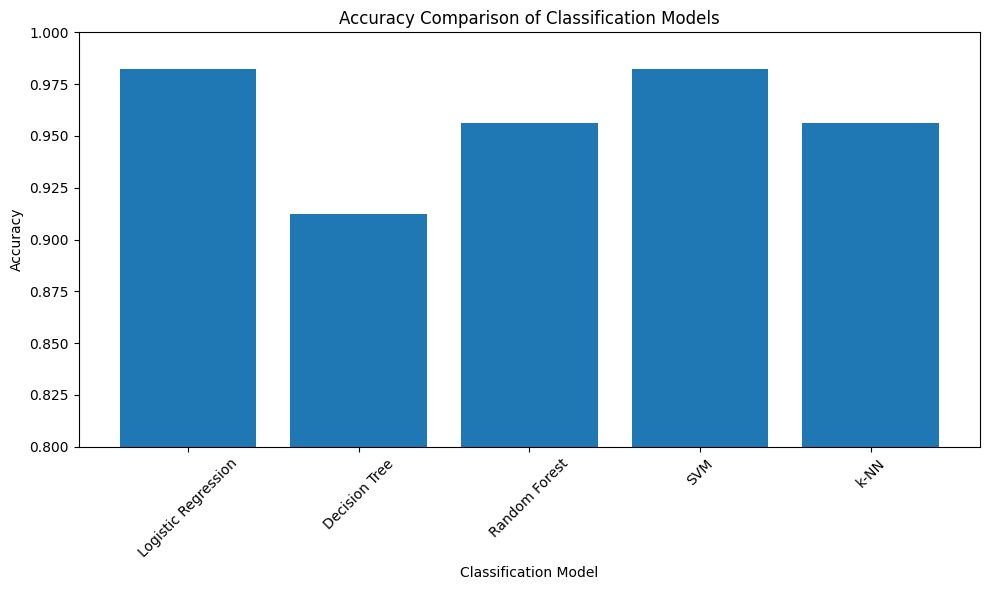

In [76]:
# Plot accuracy of all five models

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Accuracy Comparison of Classification Models")
plt.xlabel("Classification Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0.80, 1.00)

plt.tight_layout()
plt.show()

In [77]:
# Confusion matrix for Logistic Regression

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Logistic Regression Confusion Matrix:")
print(cm_logistic)

Logistic Regression Confusion Matrix:
[[41  1]
 [ 1 71]]


In [78]:
# Confusion matrix for Decision Tree

cm_tree = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree Confusion Matrix:")
print(cm_tree)

Decision Tree Confusion Matrix:
[[39  3]
 [ 7 65]]


In [79]:
# Confusion matrix for Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[39  3]
 [ 2 70]]


In [80]:
# Confusion matrix for SVM

cm_svm = confusion_matrix(y_test, y_pred_svm)

print("SVM Confusion Matrix:")
print(cm_svm)

SVM Confusion Matrix:
[[41  1]
 [ 1 71]]


In [81]:
# Confusion matrix for k-NN

cm_knn = confusion_matrix(y_test, y_pred_knn)

print("k-NN Confusion Matrix:")
print(cm_knn)

k-NN Confusion Matrix:
[[39  3]
 [ 2 70]]


In [82]:
# Identify models with highest and lowest accuracy

best_model = results_df.loc[
    results_df["Accuracy"].idxmax()
]

worst_model = results_df.loc[
    results_df["Accuracy"].idxmin()
]

print("Model with the highest accuracy:")
print(best_model["Model"])
print("Accuracy:", round(best_model["Accuracy"], 4))

print("\nModel with the lowest accuracy:")
print(worst_model["Model"])
print("Accuracy:", round(worst_model["Accuracy"], 4))

Model with the highest accuracy:
Logistic Regression
Accuracy: 0.9825

Model with the lowest accuracy:
Decision Tree
Accuracy: 0.9123


In [83]:
# Display final comparison table

print("FINAL MODEL COMPARISON")
print("=" * 70)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861
1,Decision Tree,0.9123,0.9559,0.9028,0.9286
2,Random Forest,0.9561,0.9589,0.9722,0.9655
3,SVM,0.9825,0.9861,0.9861,0.9861
4,k-NN,0.9561,0.9589,0.9722,0.9655


The performance of all five models was compared using Accuracy, Precision,
Recall, and F1 Score.

The model with the highest accuracy in the experiment is identified as the
best-performing model based on accuracy, while the model with the lowest
accuracy is identified as the lowest-performing model based on accuracy.

The final results should be considered in the context of all evaluation
metrics rather than accuracy alone.